# Aula 6 — Desocupação por sexo (2012 × 2026) e afazeres domésticos

Nesta aula juntamos:
- **Tabela 5 (2012 T1)** e **Tabela 5 (2026 T1)**: composição das pessoas desocupadas por sexo (% homens e % mulheres) em cada estado
- **Tabela 1.1.1 (IBGE, 2022)**: horas semanais dedicadas a cuidados de pessoas e/ou afazeres domésticos (a mesma da Aula 2)

**Roteiro:**
1. Abrir e juntar (`merge`) as duas Tabelas 5
2. Comparar a participação das mulheres entre 2012 e 2026
3. Gráfico de barras com seaborn usando a tabela do merge
4. Tratar a Tabela 1.1.1 com o código da Aula 2 (só os estados)
5. Cruzar desocupação com horas de afazeres domésticos

In [1]:
# No terminal, uma vez: python -m pip install pandas matplotlib seaborn xlrd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1 - Abrindo as duas Tabelas 5

Os CSVs usam `;` como separador e vírgula decimal. Eles foram salvos em UTF-8 com BOM, por isso `encoding="utf-8-sig"` (assim a 1ª coluna não vira `\ufeffSigla`).

In [2]:
t2012 = pd.read_csv("Tabela5-sem_emprego_2012.csv", sep=";", decimal=",", encoding="utf-8-sig")
t2026 = pd.read_csv("Tabela5-sem_emprego_2026.csv", sep=";", decimal=",", encoding="utf-8-sig")

t2012.head()

,Sigla,Código,Estado,Desocupados - homens (2012 T1),Desocupados - mulheres (2012 T1)
0,AC,12,Acre,45.3,54.7
1,AL,27,Alagoas,44.7,55.3
2,AM,13,Amazonas,47.5,52.5
3,AP,16,Amapá,48.1,51.9
4,BA,29,Bahia,43.8,56.2


Os nomes das colunas são longos e têm o ano no meio. Vamos renomear para `homens_2012`, `mulheres_2012` etc. Assim, depois do merge, fica claro de que ano é cada coluna.

In [3]:
t2012 = t2012.rename(columns={
    "Desocupados - homens (2012 T1)": "homens_2012",
    "Desocupados - mulheres (2012 T1)": "mulheres_2012",
})
t2026 = t2026.rename(columns={
    "Desocupados - homens (2026 T1)": "homens_2026",
    "Desocupados - mulheres (2026 T1)": "mulheres_2026",
})

print(t2012.columns.tolist())
print(t2026.columns.tolist())

['Sigla', 'Código', 'Estado', 'homens_2012', 'mulheres_2012']
['Sigla', 'Código', 'Estado', 'homens_2026', 'mulheres_2026']


### Juntando as duas tabelas com `merge`

As colunas em comum (`Sigla`, `Código`, `Estado`) são a "chave" que liga as linhas. Com `how="inner"` ficam só os estados que existem nas duas tabelas.

In [4]:
comp = t2012.merge(t2026, on=["Sigla", "Código", "Estado"], how="inner")

print(f"2012: {len(t2012)} estados | 2026: {len(t2026)} estados | merge: {len(comp)} estados")
comp.head()

2012: 27 estados | 2026: 27 estados | merge: 27 estados


,Sigla,Código,Estado,homens_2012,mulheres_2012,homens_2026,mulheres_2026
0,AC,12,Acre,45.3,54.7,53.2,46.8
1,AL,27,Alagoas,44.7,55.3,50.7,49.3
2,AM,13,Amazonas,47.5,52.5,46.8,53.2
3,AP,16,Amapá,48.1,51.9,51.1,48.9
4,BA,29,Bahia,43.8,56.2,44.7,55.3


## 2 - Comparando 2012 × 2026

`variacao_mulheres` = pontos percentuais que a participação feminina entre os desocupados subiu (+) ou caiu (−).

In [5]:
comp["variacao_mulheres"] = (comp["mulheres_2026"] - comp["mulheres_2012"]).round(1)

comp.sort_values("variacao_mulheres", ascending=False)[
    ["Sigla", "Estado", "mulheres_2012", "mulheres_2026", "variacao_mulheres"]
].reset_index(drop=True)

,Sigla,Estado,mulheres_2012,mulheres_2026,variacao_mulheres
0,RO,Rondônia,56.6,67.0,10.4
1,TO,Tocantins,44.7,53.8,9.1
2,SE,Sergipe,53.5,59.7,6.2
3,RN,Rio Grande do Norte,49.0,51.8,2.8
4,MS,Mato Grosso do Sul,52.8,54.7,1.9
5,MT,Mato Grosso,55.9,57.2,1.3
6,AM,Amazonas,52.5,53.2,0.7
7,SP,São Paulo,54.6,53.8,-0.8
8,BA,Bahia,56.2,55.3,-0.9
9,ES,Espírito Santo,53.6,52.5,-1.1


In [6]:
aumentou = comp[comp["variacao_mulheres"] > 0]
diminuiu = comp[comp["variacao_mulheres"] < 0]

print(f"Estados onde a participação das mulheres entre os desocupados AUMENTOU: {len(aumentou)}")
print(", ".join(aumentou.sort_values("variacao_mulheres", ascending=False)["Sigla"]))
print()
print(f"Estados onde DIMINUIU: {len(diminuiu)}")
print(", ".join(diminuiu.sort_values("variacao_mulheres")["Sigla"]))
print()
print(f"Mulheres são maioria entre os desocupados em 2012: {(comp['mulheres_2012'] > 50).sum()} estados")
print(f"Mulheres são maioria entre os desocupados em 2026: {(comp['mulheres_2026'] > 50).sum()} estados")
print()
print(f"Média entre os estados -> 2012: {comp['mulheres_2012'].mean():.1f}% | 2026: {comp['mulheres_2026'].mean():.1f}%")

Estados onde a participação das mulheres entre os desocupados AUMENTOU: 7
RO, TO, SE, RN, MS, MT, AM

Estados onde DIMINUIU: 20
AC, DF, GO, AL, PR, MG, PA, PE, RS, PB, PI, AP, SC, MA, CE, RR, RJ, ES, BA, SP

Mulheres são maioria entre os desocupados em 2012: 23 estados
Mulheres são maioria entre os desocupados em 2026: 22 estados

Média entre os estados -> 2012: 54.6% | 2026: 53.0%


## 3 - Gráfico usando o merge

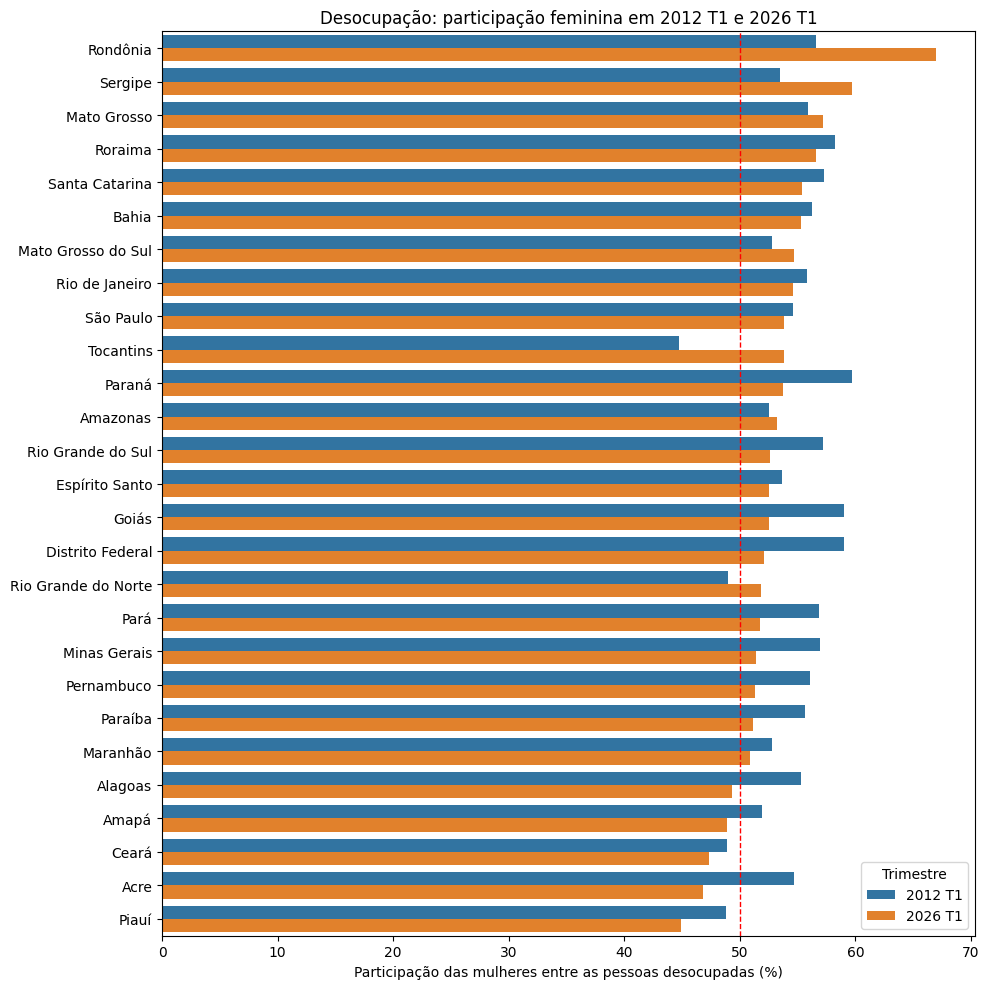

In [7]:
ordem = comp.sort_values("mulheres_2026", ascending=False)["Estado"]

longo = comp.melt(
    id_vars=["Sigla", "Código", "Estado"],
    value_vars=["mulheres_2012", "mulheres_2026"],
    var_name="Ano",
    value_name="Participacao_mulheres",
)
longo["Ano"] = longo["Ano"].map({"mulheres_2012": "2012 T1", "mulheres_2026": "2026 T1"})

fig, ax = plt.subplots(figsize=(10, 10))
sns.barplot(
    data=longo,
    y="Estado",
    x="Participacao_mulheres",
    hue="Ano",
    order=ordem,
    ax=ax,
)
ax.axvline(50, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Participação das mulheres entre as pessoas desocupadas (%)")
ax.set_ylabel("")
ax.set_title("Desocupação: participação feminina em 2012 T1 e 2026 T1")
ax.legend(title="Trimestre")
fig.tight_layout()
fig.savefig("desocupacao_mulheres_2012_2026.png", dpi=150)
plt.show()

A linha vermelha tracejada marca **50%**: à direita dela, as mulheres são **maioria** entre as pessoas desocupadas do estado.

## 4 - Tratando a Tabela 1.1.1 (código da Aula 2)

Mesmo tratamento da Aula 2: ler sem cabeçalho, cortar título e notas, nomear as colunas e converter para número.
Depois ficamos **só com os estados**, tirando a linha *Brasil* e as 5 Grandes Regiões.

In [8]:
bruto = pd.read_excel("Tabela_1.1.1.xls", engine="xlrd", header=None)

# Linhas 0–7: título/cabeçalho  |  8–40: resultados  |  41+: fonte e notas
indicador_1 = bruto.iloc[8:41].copy()
indicador_1.columns = [
    "uf_regiao",
    "total",
    "total_branca",
    "total_preta_parda",
    "homem_branca",
    "homem_preta_parda",
    "mulher_branca",
    "mulher_preta_parda",
]
indicador_1 = indicador_1.reset_index(drop=True)
indicador_1["uf_regiao"] = indicador_1["uf_regiao"].astype(str).str.strip()

for col in indicador_1.columns[1:]:
    indicador_1[col] = pd.to_numeric(indicador_1[col], errors="coerce")

# apenas os estados
regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]
estados_horas = indicador_1[~indicador_1["uf_regiao"].isin(["Brasil"] + regioes)].copy()
estados_horas = estados_horas.rename(columns={"uf_regiao": "Estado"}).reset_index(drop=True)

print(f"Estados: {len(estados_horas)}")
estados_horas.head()

Estados: 27


,Estado,total,total_branca,total_preta_parda,homem_branca,homem_preta_parda,mulher_branca,mulher_preta_parda
0,Rondônia,17.014162,16.727733,17.101523,12.111127,12.544080,20.412887,21.061410
1,Acre,13.606903,13.806929,13.541399,10.796120,9.686983,16.130352,16.710754
2,Amazonas,16.807290,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986
3,Roraima,13.639257,13.651755,13.633606,10.814803,10.476601,16.135877,16.560244
4,Pará,16.474268,16.181627,16.560239,11.524306,11.026707,19.835110,21.591144


A Tabela 1.1.1 separa homens e mulheres por cor ou raça, mas não traz um total de homens e de mulheres. Assim como na Aula 2, usamos a **média das duas colunas de cor** como aproximação das horas de homens e de mulheres.
Também criamos `diferenca_horas`: quantas horas por semana as mulheres dedicam a mais que os homens.

In [9]:
estados_horas["horas_homens"] = (estados_horas["homem_branca"] + estados_horas["homem_preta_parda"]) / 2
estados_horas["horas_mulheres"] = (estados_horas["mulher_branca"] + estados_horas["mulher_preta_parda"]) / 2
estados_horas["diferenca_horas"] = estados_horas["horas_mulheres"] - estados_horas["horas_homens"]

horas = estados_horas[["Estado", "total", "horas_homens", "horas_mulheres", "diferenca_horas"]].round(2)
horas.head()

,Estado,total,horas_homens,horas_mulheres,diferenca_horas
0,Rondônia,17.01,12.33,20.74,8.41
1,Acre,13.61,10.24,16.42,6.18
2,Amazonas,16.81,12.53,19.74,7.21
3,Roraima,13.64,10.65,16.35,5.70
4,Pará,16.47,11.28,20.71,9.44


## 5 - Cruzando desocupação com afazeres domésticos

A Tabela 1.1.1 não tem `Sigla` nem `Código`, então o merge é feito pelo nome do `Estado`.

In [10]:
cruzada = comp.merge(horas, on="Estado", how="inner")

print(f"Estados no cruzamento: {len(cruzada)}")  # tem que dar 27
faltando = set(comp["Estado"]) - set(cruzada["Estado"])
print("Estados que não casaram:", faltando if faltando else "nenhum")

cruzada[["Sigla", "Estado", "mulheres_2012", "mulheres_2026", "horas_mulheres", "diferenca_horas"]].head()

Estados no cruzamento: 27
Estados que não casaram: nenhum


,Sigla,Estado,mulheres_2012,mulheres_2026,horas_mulheres,diferenca_horas
0,AC,Acre,54.7,46.8,16.42,6.18
1,AL,Alagoas,55.3,49.3,24.98,12.24
2,AM,Amazonas,52.5,53.2,19.74,7.21
3,AP,Amapá,51.9,48.9,16.28,5.35
4,BA,Bahia,56.2,55.3,22.89,12.13


### Existe relação?

A **correlação** (`corr`) vai de −1 a 1:
- perto de **1** → quando uma cresce, a outra também cresce
- perto de **−1** → quando uma cresce, a outra diminui
- perto de **0** → não há relação linear

In [11]:
colunas = ["mulheres_2012", "mulheres_2026", "horas_mulheres", "diferenca_horas"]
cruzada[colunas].corr().round(2)

,mulheres_2012,mulheres_2026,horas_mulheres,diferenca_horas
mulheres_2012,1.00,0.31,-0.24,-0.22
mulheres_2026,0.31,1.00,-0.09,-0.07
horas_mulheres,-0.24,-0.09,1.00,0.95
diferenca_horas,-0.22,-0.07,0.95,1.00


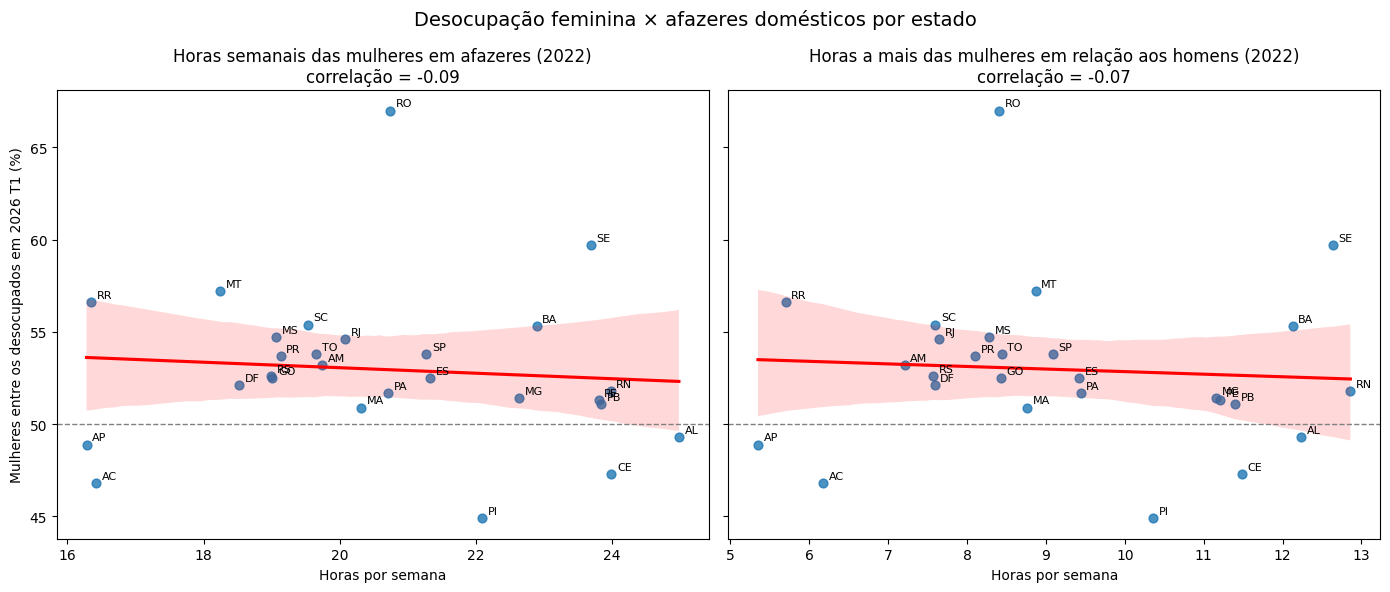

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, col, titulo in [
    (axes[0], "horas_mulheres", "Horas semanais das mulheres em afazeres (2022)"),
    (axes[1], "diferenca_horas", "Horas a mais das mulheres em relação aos homens (2022)"),
]:
    sns.regplot(data=cruzada, x=col, y="mulheres_2026", ax=ax,
                scatter_kws={"s": 40}, line_kws={"color": "red"})
    for _, linha in cruzada.iterrows():
        ax.annotate(linha["Sigla"], (linha[col], linha["mulheres_2026"]),
                    textcoords="offset points", xytext=(4, 3), fontsize=8)
    r = cruzada[col].corr(cruzada["mulheres_2026"])
    ax.set_title(f"{titulo}\ncorrelação = {r:.2f}")
    ax.set_xlabel("Horas por semana")
    ax.axhline(50, color="gray", linestyle="--", linewidth=1)

axes[0].set_ylabel("Mulheres entre os desocupados em 2026 T1 (%)")
axes[1].set_ylabel("")
fig.suptitle("Desocupação feminina × afazeres domésticos por estado", fontsize=14)
fig.tight_layout()
fig.savefig("desocupacao_x_afazeres.png", dpi=150)
plt.show()

## Conclusão

In [13]:
r_horas = cruzada["horas_mulheres"].corr(cruzada["mulheres_2026"])
r_dif = cruzada["diferenca_horas"].corr(cruzada["mulheres_2026"])

def intensidade(r):
    r = abs(r)
    return "fraca" if r < 0.3 else "moderada" if r < 0.7 else "forte"

print(f"- Média da participação feminina entre os desocupados: {comp['mulheres_2012'].mean():.1f}% (2012) -> {comp['mulheres_2026'].mean():.1f}% (2026)")
print(f"- A participação das mulheres caiu em {len(diminuiu)} estados e subiu em {len(aumentou)}.")
print(f"- Mesmo assim, as mulheres ainda são maioria entre os desocupados em {(comp['mulheres_2026'] > 50).sum()} de 27 estados em 2026.")
print(f"- Correlação com as horas de afazeres das mulheres: {r_horas:.2f} ({intensidade(r_horas)})")
print(f"- Correlação com a diferença de horas mulheres-homens: {r_dif:.2f} ({intensidade(r_dif)})")

- Média da participação feminina entre os desocupados: 54.6% (2012) -> 53.0% (2026)
- A participação das mulheres caiu em 20 estados e subiu em 7.
- Mesmo assim, as mulheres ainda são maioria entre os desocupados em 22 de 27 estados em 2026.
- Correlação com as horas de afazeres das mulheres: -0.09 (fraca)
- Correlação com a diferença de horas mulheres-homens: -0.07 (fraca)


> ⚠️ **Correlação não é causalidade.** Além disso, são só 27 pontos e os dados são de anos diferentes (afazeres em 2022, desocupação em 2026), então o cruzamento serve para **levantar hipóteses**, não para tirar conclusões definitivas.